# PyPSA-Earth Netzwerkanalyse: Vergleich zweier Szenarien

Diese Vorlage lädt zwei PyPSA-Earth-Netzwerke ein und bereitet eine saubere Basis für spätere Auswertungen vor.

Die Notebook-Struktur ist bewusst schlank gehalten:
1. Pakete importieren  
2. zentrale Pfade definieren  
3. zwei Netzwerke laden  
4. optionale Zusatzdateien laden  
5. kurze Plausibilitätsübersicht anzeigen  

Weitere Analyse- und Plot-Blöcke können später darunter eingefügt werden.

## 1. Pakete importieren

In [18]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import glob
import logging
import cartopy.crs as ccrs
import fiona
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker

# ------------------------------------------------------------
# Notebook-Einstellungen
# ------------------------------------------------------------
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

logging.getLogger("pypsa.io").setLevel(logging.ERROR)

plt.rcParams["figure.dpi"] = 120
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

## 2. Zentraler Pfadblock

Hier werden alle Pfade eingetragen, die für die Analyse benötigt werden.

Wichtig:
- `NETWORK_PATH_SCENARIO_A` und `NETWORK_PATH_SCENARIO_B` sind Pflicht.
- Alle anderen Dateien sind optional und können leer bleiben, falls sie für die spätere Analyse nicht benötigt werden.
- Die Pfade können als Windows-WSL-Pfade (`/mnt/c/...`) oder Linux-Pfade eingetragen werden.

In [19]:
# ============================================================
# ZENTRALER PFADBLOCK
# ============================================================

# Projektordner deines PyPSA-Earth-Forks
PROJECT_ROOT = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal")

# Namen der Szenarien für Tabellen, Plots und spätere Vergleiche
SCENARIO_A_NAME = "EGS"
SCENARIO_B_NAME = "without EGS"

# ------------------------------------------------------------
# Pflicht: Netzwerkdateien
# ------------------------------------------------------------
#EGS
NETWORK_PATH_SCENARIO_A = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc")
#without EGS
NETWORK_PATH_SCENARIO_B = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/Without_EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc")

# ------------------------------------------------------------
# Optional: Config-Dateien
# ------------------------------------------------------------

CONFIG_PATH_SCENARIO_A = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/SCENARIO_A/configs/config.yaml")

CONFIG_PATH_SCENARIO_B = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/SCENARIO_B/configs/config.yaml")

# ------------------------------------------------------------
# Optional: Geodaten
# ------------------------------------------------------------

COUNTRY_SHAPES_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/shapes/country_shapes.geojson")

GADM_SHAPES_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/gadm/gadm41_JPN/gadm41_JPN.gpkg")

GADM_SHAPES_PATH_10 = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/gadm/gadm41_JPN/old/OUTPUT.gpkg")

REGIONS_ONSHORE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/bus_regions/regions_onshore_elec_s_10.geojson")

REGIONS_OFFSHORE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/bus_regions/regions_offshore_elec_s_10.geojson")

# ------------------------------------------------------------
# Optional: Profil- und Ressourcen-Dateien
# ------------------------------------------------------------

SOLAR_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_solar.nc")

ONWIND_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_onwind.nc")

OFFWIND_AC_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_offwind-ac.nc")

OFFWIND_DC_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_offwind-dc.nc")

HYDRO_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_hydro.nc")

EGS_POTENTIAL_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/egs_potentials_10_2050.csv")

# ------------------------------------------------------------
# Optional: Ausgabeordner für spätere Grafiken und Tabellen
# ------------------------------------------------------------

OUTPUT_DIR = Path("./outputs_scenario_comparison")

## 3. Hilfsfunktionen zum Laden von Dateien

Die folgenden Funktionen prüfen zuerst, ob eine Datei existiert. Dadurch bricht das Notebook nicht sofort ab, wenn optionale Dateien noch nicht eingetragen sind.

In [20]:
def path_exists(path):
    """Returns True if path is a valid existing file or directory."""
    if path is None:
        return False
    path = Path(path)
    return str(path).strip() != "" and path.exists()


def require_file(path, label):
    """Raises a clear error if a required file does not exist."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"{label} wurde nicht gefunden:{path}"
            "Bitte den Pfad im zentralen Pfadblock prüfen."
        )
    return path


def load_yaml_optional(path):
    """Loads a YAML file if it exists. Otherwise returns None."""
    if not path_exists(path):
        return None

    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def load_geodata_optional(path):
    """Loads a GeoDataFrame if the file exists. Otherwise returns None."""
    if not path_exists(path):
        return None

    return gpd.read_file(path)


def load_xarray_optional(path):
    """Loads a NetCDF dataset if the file exists. Otherwise returns None."""
    if not path_exists(path):
        return None

    return xr.open_dataset(path)

## 4. Netzwerke laden

Nach diesem Block stehen beide Netzwerke als `n_a` und `n_b` zur Verfügung.

Zusätzlich wird ein Dictionary `networks` erzeugt. Das ist praktisch für spätere Schleifen über beide Szenarien.

In [21]:
# Pflichtdateien prüfen
NETWORK_PATH_SCENARIO_A = require_file(NETWORK_PATH_SCENARIO_A, "Netzwerk Szenario A")
NETWORK_PATH_SCENARIO_B = require_file(NETWORK_PATH_SCENARIO_B, "Netzwerk Szenario B")

# Netzwerke laden
n_a = pypsa.Network(NETWORK_PATH_SCENARIO_A)
n_b = pypsa.Network(NETWORK_PATH_SCENARIO_B)

# Praktische Container für spätere Vergleiche
networks = {
    SCENARIO_A_NAME: n_a,
    SCENARIO_B_NAME: n_b,
}

network_paths = {
    SCENARIO_A_NAME: NETWORK_PATH_SCENARIO_A,
    SCENARIO_B_NAME: NETWORK_PATH_SCENARIO_B,
}

print("Netzwerke erfolgreich geladen:")
for scenario_name, network_path in network_paths.items():
    print(f"- {scenario_name}: {network_path}")

Netzwerke erfolgreich geladen:
- EGS: /mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc
- without EGS: /mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/Without_EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc


## 5. Optionale Zusatzdateien laden

Dieser Block lädt Configs, Geodaten und Ressourcenprofile, falls die Pfade existieren.

Wenn eine Datei nicht existiert, wird einfach `None` gespeichert. Dadurch kannst du später gezielt prüfen, ob die jeweilige Datei verfügbar ist.

In [22]:
# ------------------------------------------------------------
# Configs
# ------------------------------------------------------------

cfg_a = load_yaml_optional(CONFIG_PATH_SCENARIO_A)
cfg_b = load_yaml_optional(CONFIG_PATH_SCENARIO_B)

configs = {
    SCENARIO_A_NAME: cfg_a,
    SCENARIO_B_NAME: cfg_b,
}

# ------------------------------------------------------------
# Geodaten
# ------------------------------------------------------------

country_shapes = load_geodata_optional(COUNTRY_SHAPES_PATH)
gadm_shapes = load_geodata_optional(GADM_SHAPES_PATH)
gadm_shapes_10 = load_geodata_optional(GADM_SHAPES_PATH_10)
regions_onshore = load_geodata_optional(REGIONS_ONSHORE_PATH)
regions_offshore = load_geodata_optional(REGIONS_OFFSHORE_PATH)

geo_data = {
    "country_shapes": country_shapes,
    "gadm_shapes": gadm_shapes,
    "gadm_shapes_10": gadm_shapes_10,
    "regions_onshore": regions_onshore,
    "regions_offshore": regions_offshore,
}

# ------------------------------------------------------------
# Ressourcenprofile
# ------------------------------------------------------------

solar_profile = load_xarray_optional(SOLAR_PROFILE_PATH)
onwind_profile = load_xarray_optional(ONWIND_PROFILE_PATH)
offwind_ac_profile = load_xarray_optional(OFFWIND_AC_PROFILE_PATH)
offwind_dc_profile = load_xarray_optional(OFFWIND_DC_PROFILE_PATH)
hydro_profile = load_xarray_optional(HYDRO_PROFILE_PATH)

profiles = {
    "solar": solar_profile,
    "onwind": onwind_profile,
    "offwind_ac": offwind_ac_profile,
    "offwind_dc": offwind_dc_profile,
    "hydro": hydro_profile,
}

# ------------------------------------------------------------
# Ausgabeordner anlegen
# ------------------------------------------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Optionale Dateien geladen, soweit vorhanden.")
print(f"Ausgabeordner: {OUTPUT_DIR.resolve()}")

Optionale Dateien geladen, soweit vorhanden.
Ausgabeordner: /mnt/c/Users/nikla/Documents/Git/EGS-Analyse-Notebooks/Notebooks/outputs_scenario_comparison


## 6. Plausibilitätsübersicht

Dieser Block zeigt eine kurze Übersicht beider Netzwerke. So kannst du direkt prüfen, ob die richtigen Dateien geladen wurden.

In [23]:
def network_overview(network, scenario_name):
    """Creates a compact overview table for a PyPSA network."""
    objective = getattr(network, "objective", np.nan)

    return {
        "Szenario": scenario_name,
        "Snapshots": len(network.snapshots),
        "Start": network.snapshots.min() if len(network.snapshots) > 0 else None,
        "Ende": network.snapshots.max() if len(network.snapshots) > 0 else None,
        "Buses": len(network.buses),
        "Generators": len(network.generators),
        "Links": len(network.links),
        "Stores": len(network.stores),
        "Storage Units": len(network.storage_units),
        "Loads": len(network.loads),
        "Lines": len(network.lines),
        "Objective": objective,
    }


overview = pd.DataFrame(
    [
        network_overview(n, scenario_name)
        for scenario_name, n in networks.items()
    ]
)

display(overview)

,Szenario,Snapshots,Start,Ende,Buses,Generators,Links,Stores,Storage Units,Loads,Lines,Objective
0,EGS,61,2013-01-01,2013-12-27,1182,1864,3199,754,91,1421,88,1.009667e+11
1,without EGS,61,2013-01-01,2013-12-27,1134,1815,3058,754,44,1421,88,1.054113e+11


## 7. Verfügbare Carrier prüfen

Dieser Block zeigt, welche Carrier in beiden Netzwerken vorkommen. Das ist hilfreich, bevor später technologiespezifische Auswertungen erstellt werden.

In [24]:
def collect_carriers(network):
    """Collects carriers from the most relevant PyPSA component tables."""
    carrier_parts = []

    for component_name in ["buses", "generators", "links", "stores", "storage_units", "loads"]:
        table = getattr(network, component_name, None)

        if table is None or table.empty or "carrier" not in table.columns:
            continue

        carriers = (
            table["carrier"]
            .dropna()
            .astype(str)
            .replace("", np.nan)
            .dropna()
            .unique()
            .tolist()
        )

        carrier_parts.extend(carriers)

    return sorted(set(carrier_parts))


carrier_overview = pd.DataFrame({
    scenario_name: pd.Series(collect_carriers(network))
    for scenario_name, network in networks.items()
})

display(carrier_overview)

,EGS,without EGS
0,AC,AC
1,Alkaline electrolyzer large,Alkaline electrolyzer large
2,B2B,B2B
3,BEV charger,BEV charger
4,CCGT,CCGT
...,...,...
132,urban central solid biomass CHP,urban central water tanks charger
133,urban central solid biomass CHP CC,urban central water tanks discharger
134,urban central water tanks,NaN
135,urban central water tanks charger,NaN


## 1. Kosten Analyse

Analyse des bestehenden Netzwerks zum Abgleich mit dem tatsächlichen Ist-Stand

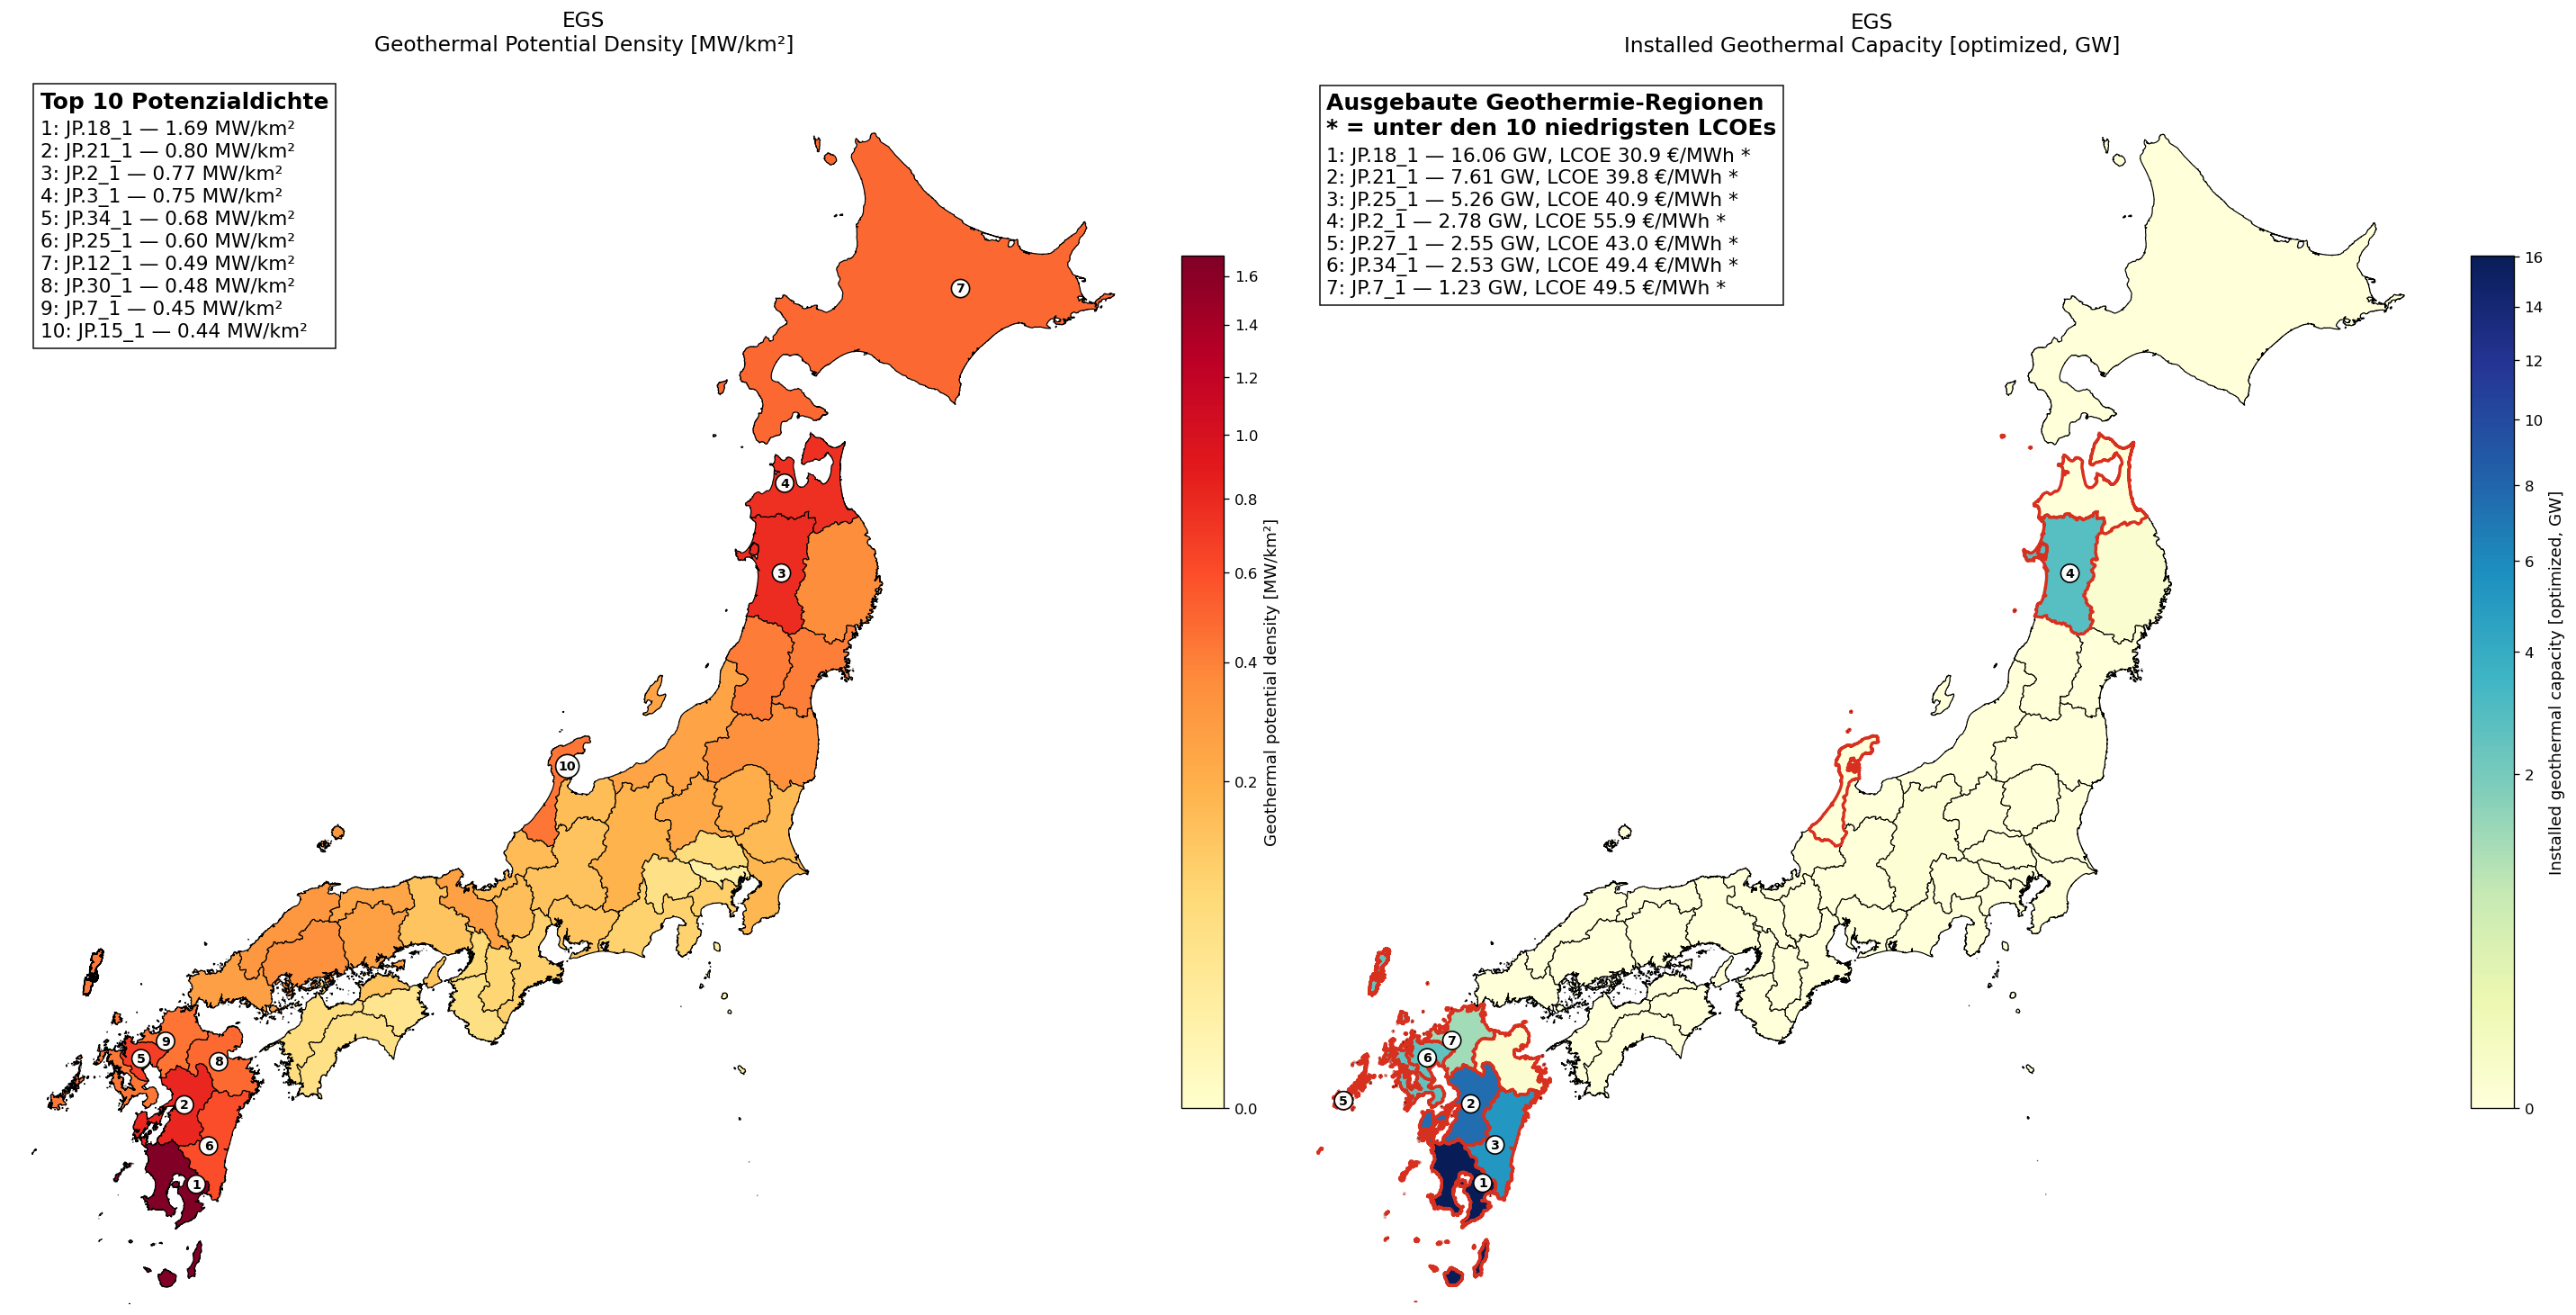

In [27]:
# ============================================================
# EGS-Karten für Szenario A
#
# Linke Karte:
# - Geothermal Potential Density [MW/km²]
# - Nummerierte Top-Regionen nach Potenzialdichte
#
# Rechte Karte:
# - Installed Geothermal Capacity [optimized, GW]
# - Nummerierte Regionen mit ausgebauter Geothermie
# - LCOE aus regionaler CSV
# - Markierung der 10 Regionen mit niedrigstem LCOE
#
# Keine Tabellen
# Keine Heat-/El-Kosten
# Keine Pfeil-Labels
# ============================================================


# ------------------------------------------------------------
# 0) Netzwerk und Szenario
# ------------------------------------------------------------

n = n_a

scenario_name = (
    SCENARIO_A_NAME
    if "SCENARIO_A_NAME" in globals()
    else "EGS"
)


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

EGS_POTENTIAL_PATH = Path(
    "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/egs_potentials_10_2050.csv"
)

# Aggregierte regionale LCOE-Datei aus deiner Gringarten-Auswertung
EGS_REGION_LCOE_PATH = Path(
    "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/egs_data/egs_gringarten_japan_gadm1.csv"
)

potential_column = "p_nom_max"

# Falls p_nom_max in der CSV bereits in GW steht: "GW"
# Falls p_nom_max in MW steht: "MW"
potential_input_unit = "GW"

electric_bus_carriers = ["AC", "DC", "low voltage"]

# "optimized" = p_nom_opt
# "current"   = p_nom
capacity_mode = "optimized"

simulation_gadm_level = 1

potential_density_cmap = "YlOrRd"
installed_capacity_cmap = "YlGnBu"

# Linke Karte: Top-N Regionen nach Potenzialdichte nummerieren
top_n_density_labels = 10

# Rechte Karte: alle Regionen mit Capacity > threshold nummerieren
installed_capacity_label_threshold_GW = 0.01

# Die 10 Regionen mit den niedrigsten regionalen LCOEs markieren
n_lowest_lcoe_regions = 10

# Japan extent
map_extent = [128.0, 146.5, 30.0, 46.5]


# ------------------------------------------------------------
# Legend settings
# Position:
# x/y in Achsenkoordinaten:
#   (0, 0) = unten links
#   (1, 1) = oben rechts
# ------------------------------------------------------------

LEFT_LEGEND_TITLE = f"Top {top_n_density_labels} Potenzialdichte"
RIGHT_LEGEND_TITLE = (
    "Ausgebaute Geothermie-Regionen\n"
    f"* = unter den {n_lowest_lcoe_regions} niedrigsten LCOEs"
)

# Legendenpositionen
LEFT_LEGEND_X = 0.02
LEFT_LEGEND_Y = 0.98

RIGHT_LEGEND_X = 0.02
RIGHT_LEGEND_Y = 0.98

# Ankerpunkte
LEFT_LEGEND_HA = "left"
LEFT_LEGEND_VA = "top"

RIGHT_LEGEND_HA = "left"
RIGHT_LEGEND_VA = "top"

# Schriftgrößen
LEFT_LEGEND_FONTSIZE = 13
LEFT_LEGEND_TITLE_FONTSIZE = 15

RIGHT_LEGEND_FONTSIZE = 13
RIGHT_LEGEND_TITLE_FONTSIZE = 15

# Größe / Abstand / Transparenz
LEFT_LEGEND_BOX_PAD = 0.45
RIGHT_LEGEND_BOX_PAD = 0.45

LEFT_LEGEND_BOX_ALPHA = 0.96
RIGHT_LEGEND_BOX_ALPHA = 0.96

LEFT_LEGEND_LINE_SPACING = 1.25
RIGHT_LEGEND_LINE_SPACING = 1.22

LEFT_LEGEND_TITLE_BODY_SPACING = 5
RIGHT_LEGEND_TITLE_BODY_SPACING = 5


# ------------------------------------------------------------
# Number marker settings
# ------------------------------------------------------------

NUMBER_MARKER_FONTSIZE = 8.5
NUMBER_MARKER_FACE_COLOR = "white"
NUMBER_MARKER_EDGE_COLOR = "black"
NUMBER_MARKER_TEXT_COLOR = "black"

LOWEST_LCOE_EDGE_COLOR = "#d7301f"
LOWEST_LCOE_LINEWIDTH = 2.0


# ------------------------------------------------------------
# Helper: GADM robust laden
# ------------------------------------------------------------

def find_gadm_layer(gpkg_path, gadm_level):
    gpkg_path = Path(gpkg_path)

    target = f"ADM_ADM_{gadm_level}"
    layers = fiona.listlayers(str(gpkg_path))

    matches = [
        layer for layer in layers
        if layer.endswith(target) or target in layer
    ]

    if not matches:
        raise ValueError(
            f"Kein Layer für {target} in {gpkg_path} gefunden. "
            f"Vorhandene Layer: {layers}"
        )

    return matches[0]


def read_gadm_layer(gpkg_path, gadm_level):
    gpkg_path = Path(gpkg_path)

    if gpkg_path.suffix.lower() == ".gpkg":
        layer = find_gadm_layer(gpkg_path, gadm_level)
        gdf = gpd.read_file(gpkg_path, layer=layer)
    else:
        gdf = gpd.read_file(gpkg_path)

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    return gdf.to_crs("EPSG:4326")


def infer_region_id_col(gdf, gadm_level=1):
    candidates = [
        "GADM_ID",
        f"GID_{gadm_level}",
        "GID_2",
        "GID_1",
        "region",
        "name",
        "Name",
        "NAME_2",
        "NAME_1",
    ]

    for col in candidates:
        if col in gdf.columns:
            return col

    raise ValueError(
        "Keine passende Regions-ID-Spalte gefunden. "
        f"Vorhandene Spalten: {list(gdf.columns)}"
    )


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def get_capacity(df, nominal_col="p_nom", mode="optimized"):
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0.0, index=df.index)


def bus_to_region(bus_name):
    """
    Convert PyPSA bus names to GADM region names.

    Examples:
    JP.10_1_AC                 -> JP.10_1
    JP.10_1 urban central heat -> JP.10_1
    JP.10_1 geothermal heat    -> JP.10_1
    JPN.10_1                   -> JP.10_1
    """
    s = str(bus_name).strip()

    match = pd.Series([s]).str.extract(r"^([A-Z]{2,3}\.\d+_\d+)")[0].iloc[0]

    if pd.notna(match):
        s = match

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",
        " urban central heat",
        "_urban central heat",
        " geothermal heat",
        "_geothermal heat",
        " heat",
        "_heat",
        " gas",
        "_gas",
        " oil",
        "_oil",
        " coal",
        "_coal",
        " biomass",
        "_biomass",
        " H2",
        "_H2",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    if s.startswith("JPN."):
        s = "JP." + s[len("JPN."):]

    return s


def normalize_region_id(region_id):
    return bus_to_region(region_id)


def get_bus_columns(df):
    bus_cols = [
        col for col in df.columns
        if col.startswith("bus") and col[3:].isdigit()
    ]

    return sorted(
        bus_cols,
        key=lambda x: int(x.replace("bus", ""))
    )


def choose_lcoe_column(df):
    """
    Wählt automatisch eine sinnvolle LCOE-Spalte aus der regionalen CSV.
    Priorität:
    1) gewichteter LCOE in EUR/MWh
    2) einfacher Mittelwert in EUR/MWh
    3) gewichteter LCOE in EUR/kWh
    4) einfacher Mittelwert in EUR/kWh
    """
    preferred_cols = [
        "LCOE_Gringarten_weighted_EUR_per_MWh",
        "LCOE_Gringarten_mean_EUR_per_MWh",
        "LCOE_Gringarten_weighted_EUR_per_kWh",
        "LCOE_Gringarten_mean_EUR_per_kWh",
    ]

    for col in preferred_cols:
        if col in df.columns:
            return col

    raise ValueError(
        "Keine geeignete LCOE-Spalte in der regionalen CSV gefunden. "
        f"Vorhandene Spalten: {list(df.columns)}"
    )


def format_lcoe_for_legend(value, unit):
    if pd.isna(value):
        return "n/a"

    return f"{value:.1f} {unit}"


# ------------------------------------------------------------
# Helper: Nummernmarker und Legenden
# ------------------------------------------------------------

def add_number_markers(
    ax,
    df,
    number_col="number",
    point_col="label_point",
    marker_facecolor=NUMBER_MARKER_FACE_COLOR,
    marker_edgecolor=NUMBER_MARKER_EDGE_COLOR,
    marker_text_color=NUMBER_MARKER_TEXT_COLOR,
    marker_size=NUMBER_MARKER_FONTSIZE,
    zorder=20,
):
    """
    Setzt nummerierte Marker direkt auf die Regionen.
    """
    if df.empty:
        return

    for _, row in df.iterrows():
        point = row[point_col]

        ax.text(
            point.x,
            point.y,
            str(int(row[number_col])),
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=marker_size,
            color=marker_text_color,
            fontweight="bold",
            bbox=dict(
                boxstyle="circle,pad=0.22",
                facecolor=marker_facecolor,
                edgecolor=marker_edgecolor,
                linewidth=1.0,
                alpha=0.98,
            ),
            zorder=zorder,
        )


def alignment_to_loc(ha, va):
    """
    Wandelt horizontale/vertikale Ausrichtung in Matplotlib-loc um.
    """
    ha = str(ha).lower()
    va = str(va).lower()

    if ha == "left" and va == "top":
        return "upper left"
    if ha == "right" and va == "top":
        return "upper right"
    if ha == "left" and va == "bottom":
        return "lower left"
    if ha == "right" and va == "bottom":
        return "lower right"
    if ha == "center" and va == "top":
        return "upper center"
    if ha == "center" and va == "bottom":
        return "lower center"

    return "upper left"


def add_numbered_legend_panel(
    ax,
    title,
    lines,
    x=0.02,
    y=0.98,
    ha="left",
    va="top",
    fontsize=8.0,
    title_fontsize=10.0,
    box_pad=0.45,
    box_alpha=0.96,
    line_spacing=1.25,
    title_body_spacing=5,
):
    """
    Fügt eine nummerierte Legende innerhalb der Karte hinzu.

    Position:
      x/y in ax.transAxes-Koordinaten
      (0,0) = unten links
      (1,1) = oben rechts

    Größe:
      fontsize
      title_fontsize
      box_pad
      line_spacing
    """
    if not lines:
        return

    title_area = TextArea(
        str(title),
        textprops=dict(
            fontsize=title_fontsize,
            fontweight="bold",
            linespacing=line_spacing,
        ),
    )

    body_area = TextArea(
        "\n".join([str(line) for line in lines]),
        textprops=dict(
            fontsize=fontsize,
            linespacing=line_spacing,
        ),
    )

    packed = VPacker(
        children=[title_area, body_area],
        align="left",
        pad=0,
        sep=title_body_spacing,
    )

    loc = alignment_to_loc(ha, va)

    anchored_box = AnchoredOffsetbox(
        loc=loc,
        child=packed,
        pad=box_pad,
        frameon=True,
        bbox_to_anchor=(x, y),
        bbox_transform=ax.transAxes,
        borderpad=0.0,
    )

    anchored_box.patch.set(
        facecolor="white",
        edgecolor="black",
        linewidth=0.9,
        alpha=box_alpha,
    )

    anchored_box.set_zorder(30)

    ax.add_artist(anchored_box)


# ------------------------------------------------------------
# 1) Load geothermal potential data
# ------------------------------------------------------------

egs_potentials = pd.read_csv(EGS_POTENTIAL_PATH)

if "region" not in egs_potentials.columns:
    raise ValueError(
        "Die EGS-Potenzialdatei enthält keine Spalte 'region'. "
        f"Vorhandene Spalten: {list(egs_potentials.columns)}"
    )

if potential_column not in egs_potentials.columns:
    raise ValueError(
        f"Die EGS-Potenzialdatei enthält keine Spalte '{potential_column}'. "
        f"Vorhandene Spalten: {list(egs_potentials.columns)}"
    )

egs_potentials["region_normalized"] = (
    egs_potentials["region"]
    .astype(str)
    .str.strip()
    .map(normalize_region_id)
)

if potential_input_unit.lower() == "mw":
    egs_potentials["geothermal_potential_GW"] = (
        egs_potentials[potential_column].fillna(0) / 1e3
    )
elif potential_input_unit.lower() == "gw":
    egs_potentials["geothermal_potential_GW"] = (
        egs_potentials[potential_column].fillna(0)
    )
else:
    raise ValueError("potential_input_unit muss 'MW' oder 'GW' sein.")


# ------------------------------------------------------------
# 2) GADM-Regionen vorbereiten
# ------------------------------------------------------------

regions = gadm_shapes.copy()

if regions.crs is None:
    regions = regions.set_crs("EPSG:4326")

regions = regions.to_crs("EPSG:4326")

try:
    region_id_col = infer_region_id_col(
        regions,
        gadm_level=simulation_gadm_level,
    )
except ValueError:
    regions = read_gadm_layer(
        GADM_SHAPES_PATH,
        simulation_gadm_level,
    )

    region_id_col = infer_region_id_col(
        regions,
        gadm_level=simulation_gadm_level,
    )

regions["region"] = (
    regions[region_id_col]
    .astype(str)
    .map(normalize_region_id)
)

potential_lookup = (
    egs_potentials
    .set_index("region_normalized")["geothermal_potential_GW"]
)

regions["geothermal_potential_GW"] = (
    regions["region"]
    .map(potential_lookup)
    .fillna(0)
)


# ------------------------------------------------------------
# 3) Potenzialdichte berechnen
# ------------------------------------------------------------

regions_equal_area = regions.to_crs("EPSG:6933")

regions["area_km2"] = regions_equal_area.geometry.area / 1e6

regions["geothermal_potential_density_MW_per_km2"] = (
    regions["geothermal_potential_GW"] * 1e3
    / regions["area_km2"]
)

regions["geothermal_potential_density_MW_per_km2"] = (
    regions["geothermal_potential_density_MW_per_km2"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ------------------------------------------------------------
# 4) Installierte Geothermie-Leistung aus Generatoren
# ------------------------------------------------------------

generator_geo_capacity = pd.Series(dtype=float)

if hasattr(n, "generators") and len(n.generators) > 0:
    generators = n.generators.copy()

    generators = generators[
        generators.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False,
        )
    ].copy()

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        generators["capacity_MW"] = get_capacity(
            generators,
            "p_nom",
            mode=capacity_mode,
        )

        generators["region"] = generators.bus.map(bus_to_region)

        generator_geo_capacity = (
            generators
            .groupby("region")["capacity_MW"]
            .sum()
        )


# ------------------------------------------------------------
# 5) Installierte Geothermie-Leistung aus Links
# ------------------------------------------------------------

link_geo_capacity_parts = []

if hasattr(n, "links") and len(n.links) > 0:
    links = n.links.copy()

    links = links[
        links.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False,
        )
    ].copy()

    if not links.empty:
        links["p_nom_final"] = get_capacity(
            links,
            "p_nom",
            mode=capacity_mode,
        )

        bus_cols = get_bus_columns(links)

        for bus_col in bus_cols:
            bus_number = int(bus_col.replace("bus", ""))

            if bus_number == 0:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            selected_links = links.loc[mask].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    efficiency = links.loc[mask, efficiency_col].fillna(1)
                else:
                    efficiency = links.loc[mask, efficiency_col].fillna(0)
            else:
                efficiency = 1 if bus_number == 1 else 0

            selected_links["capacity_MW"] = (
                selected_links["p_nom_final"]
                * efficiency
            )

            selected_links["region"] = selected_links[bus_col].map(bus_to_region)

            tmp = (
                selected_links
                .groupby("region")["capacity_MW"]
                .sum()
            )

            link_geo_capacity_parts.append(tmp)

if link_geo_capacity_parts:
    link_geo_capacity = (
        pd.concat(link_geo_capacity_parts)
        .groupby(level=0)
        .sum()
    )
else:
    link_geo_capacity = pd.Series(dtype=float)


# ------------------------------------------------------------
# 6) Geothermie-Leistung auf Regionen mappen
# ------------------------------------------------------------

installed_geo_capacity_by_region = (
    pd.concat(
        [
            generator_geo_capacity,
            link_geo_capacity,
        ],
        axis=0,
    )
    .groupby(level=0)
    .sum()
)

regions["installed_geothermal_capacity_MW"] = (
    regions["region"]
    .map(installed_geo_capacity_by_region)
    .fillna(0)
)

regions["installed_geothermal_capacity_GW"] = (
    regions["installed_geothermal_capacity_MW"] / 1e3
)


# ------------------------------------------------------------
# 7) Regionale LCOE-CSV laden und auf Regionen mappen
# ------------------------------------------------------------

regional_lcoe = pd.read_csv(EGS_REGION_LCOE_PATH)

if "region" not in regional_lcoe.columns:
    raise ValueError(
        "Die regionale LCOE-CSV enthält keine Spalte 'region'. "
        f"Vorhandene Spalten: {list(regional_lcoe.columns)}"
    )

regional_lcoe["region"] = (
    regional_lcoe["region"]
    .astype(str)
    .map(normalize_region_id)
)

lcoe_col_selected = choose_lcoe_column(regional_lcoe)

if lcoe_col_selected.endswith("EUR_per_MWh"):
    lcoe_display_unit = "€/MWh"
elif lcoe_col_selected.endswith("EUR_per_kWh"):
    lcoe_display_unit = "€/kWh"
else:
    lcoe_display_unit = ""

merge_cols = ["region", lcoe_col_selected]

if "region_name" in regional_lcoe.columns:
    merge_cols.append("region_name")

regional_lcoe_small = regional_lcoe[merge_cols].copy()

regional_lcoe_small = regional_lcoe_small.rename(columns={
    lcoe_col_selected: "regional_lcoe_display"
})

regions = regions.merge(
    regional_lcoe_small,
    on="region",
    how="left",
)

if "region_name" not in regions.columns:
    regions["region_name"] = regions["region"]

regions["region_name"] = regions["region_name"].fillna(regions["region"])


# ------------------------------------------------------------
# 8) Plot vorbereiten
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(24, 12),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

extent = map_extent


# ------------------------------------------------------------
# 8a) Linke Karte: Geothermal Potential Density
# ------------------------------------------------------------

left_col = "geothermal_potential_density_MW_per_km2"

if regions[left_col].max() > 0:
    left_norm = mcolors.PowerNorm(
        gamma=0.45,
        vmin=0,
        vmax=regions[left_col].max(),
    )
else:
    left_norm = mcolors.Normalize(vmin=0, vmax=1)

regions.plot(
    column=left_col,
    ax=axes[0],
    cmap=potential_density_cmap,
    norm=left_norm,
    linewidth=0.7,
    edgecolor="black",
    transform=ccrs.PlateCarree(),
)

axes[0].set_title(
    f"{scenario_name}\nGeothermal Potential Density [MW/km²]",
    fontsize=14,
)

axes[0].set_extent(extent, crs=ccrs.PlateCarree())
axes[0].axis("off")


# ------------------------------------------------------------
# 8b) Rechte Karte: Installed Geothermal Capacity
# ------------------------------------------------------------

right_col = "installed_geothermal_capacity_GW"

right_vmax = regions[right_col].max()

if right_vmax > 0:
    right_norm = mcolors.PowerNorm(
        gamma=0.45,
        vmin=0,
        vmax=right_vmax,
    )
else:
    right_norm = mcolors.Normalize(vmin=0, vmax=1)

regions.plot(
    column=right_col,
    ax=axes[1],
    cmap=installed_capacity_cmap,
    norm=right_norm,
    linewidth=0.7,
    edgecolor="black",
    transform=ccrs.PlateCarree(),
)

axes[1].set_title(
    f"{scenario_name}\nInstalled Geothermal Capacity [{capacity_mode}, GW]",
    fontsize=14,
)

axes[1].set_extent(extent, crs=ccrs.PlateCarree())
axes[1].axis("off")


# ------------------------------------------------------------
# 9) Linke Karte: Top-Regionen nummerieren und Legende erzeugen
# ------------------------------------------------------------

top_density_regions = (
    regions
    .sort_values(left_col, ascending=False)
    .head(top_n_density_labels)
    .copy()
)

top_density_regions["number"] = np.arange(1, len(top_density_regions) + 1)
top_density_regions["label_point"] = top_density_regions.geometry.representative_point()

add_number_markers(
    ax=axes[0],
    df=top_density_regions,
    number_col="number",
    point_col="label_point",
)

left_legend_lines = []

for _, row in top_density_regions.iterrows():
    left_legend_lines.append(
        f"{int(row['number'])}: {row['region']} — "
        f"{row[left_col]:.2f} MW/km²"
    )

add_numbered_legend_panel(
    ax=axes[0],
    title=LEFT_LEGEND_TITLE,
    lines=left_legend_lines,
    x=LEFT_LEGEND_X,
    y=LEFT_LEGEND_Y,
    ha=LEFT_LEGEND_HA,
    va=LEFT_LEGEND_VA,
    fontsize=LEFT_LEGEND_FONTSIZE,
    title_fontsize=LEFT_LEGEND_TITLE_FONTSIZE,
    box_pad=LEFT_LEGEND_BOX_PAD,
    box_alpha=LEFT_LEGEND_BOX_ALPHA,
    line_spacing=LEFT_LEGEND_LINE_SPACING,
    title_body_spacing=LEFT_LEGEND_TITLE_BODY_SPACING,
)


# ------------------------------------------------------------
# 10) Rechte Karte: Ausgebaute Regionen nummerieren
# ------------------------------------------------------------

built_regions = regions[
    regions[right_col] > installed_capacity_label_threshold_GW
].copy()

built_regions = built_regions.sort_values(
    right_col,
    ascending=False,
)

built_regions["number"] = np.arange(1, len(built_regions) + 1)
built_regions["label_point"] = built_regions.geometry.representative_point()

add_number_markers(
    ax=axes[1],
    df=built_regions,
    number_col="number",
    point_col="label_point",
)


# ------------------------------------------------------------
# 11) Rechte Karte: 10 Regionen mit niedrigstem LCOE markieren
# ------------------------------------------------------------

regions_with_lcoe = regions[
    regions["regional_lcoe_display"].notna()
].copy()

lowest_lcoe_regions = (
    regions_with_lcoe
    .sort_values("regional_lcoe_display", ascending=True)
    .head(n_lowest_lcoe_regions)
    .copy()
)

lowest_lcoe_region_set = set(lowest_lcoe_regions["region"])

if not lowest_lcoe_regions.empty:
    lowest_lcoe_regions.plot(
        ax=axes[1],
        facecolor="none",
        edgecolor=LOWEST_LCOE_EDGE_COLOR,
        linewidth=LOWEST_LCOE_LINEWIDTH,
        transform=ccrs.PlateCarree(),
        zorder=9,
    )


# ------------------------------------------------------------
# 12) Rechte Karte: Legende erzeugen
# ------------------------------------------------------------

right_legend_lines = []

for _, row in built_regions.iterrows():
    lcoe_text = format_lcoe_for_legend(
        row.get("regional_lcoe_display", np.nan),
        lcoe_display_unit,
    )

    lowest_marker = " *" if row["region"] in lowest_lcoe_region_set else ""

    right_legend_lines.append(
        f"{int(row['number'])}: {row['region']} — "
        f"{row[right_col]:.2f} GW, "
        f"LCOE {lcoe_text}{lowest_marker}"
    )

add_numbered_legend_panel(
    ax=axes[1],
    title=RIGHT_LEGEND_TITLE,
    lines=right_legend_lines,
    x=RIGHT_LEGEND_X,
    y=RIGHT_LEGEND_Y,
    ha=RIGHT_LEGEND_HA,
    va=RIGHT_LEGEND_VA,
    fontsize=RIGHT_LEGEND_FONTSIZE,
    title_fontsize=RIGHT_LEGEND_TITLE_FONTSIZE,
    box_pad=RIGHT_LEGEND_BOX_PAD,
    box_alpha=RIGHT_LEGEND_BOX_ALPHA,
    line_spacing=RIGHT_LEGEND_LINE_SPACING,
    title_body_spacing=RIGHT_LEGEND_TITLE_BODY_SPACING,
)


# ------------------------------------------------------------
# 13) Colorbars
# ------------------------------------------------------------

sm_left = plt.cm.ScalarMappable(
    cmap=potential_density_cmap,
    norm=left_norm,
)
sm_left.set_array([])

cbar_left = fig.colorbar(
    sm_left,
    ax=axes[0],
    orientation="vertical",
    fraction=0.035,
    pad=0.02,
)

cbar_left.set_label(
    "Geothermal potential density [MW/km²]",
    fontsize=11,
)


sm_right = plt.cm.ScalarMappable(
    cmap=installed_capacity_cmap,
    norm=right_norm,
)
sm_right.set_array([])

cbar_right = fig.colorbar(
    sm_right,
    ax=axes[1],
    orientation="vertical",
    fraction=0.035,
    pad=0.02,
)

cbar_right.set_label(
    f"Installed geothermal capacity [{capacity_mode}, GW]",
    fontsize=11,
)


# ------------------------------------------------------------
# 14) Plot anzeigen
# ------------------------------------------------------------

plt.tight_layout()
plt.show()